# Mini Data Visualization Challenge 


This notebook shows **three example plots** 

---

### Key design choices modelled here
| Choice | Rationale |
|--------|-----------|
| Consistent color palette across plots | Catalyst A = green, B = purple throughout |
| Solid vs dashed line for pressure | Redundant encoding: works in B&W print too |
| y-axis from 0 for conversion, not for selectivity | 0 is meaningful for conversion (none → complete); selectivity range is 0.35–0.95, so starting at 0 would compress the signal |
| Scatter for conversion–selectivity trade-off | Shows the continuous relationship, not a trend over time |
| Residence time as hue in scatter | Third variable encoded without a 3D plot |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('reactor_data.csv')

# Consistent palette — use across all plots
CAT_COLORS = {'A': '#2ca02c', 'B': '#9467bd'}
PRESSURE_STYLES = {1: '-', 5: '--'}
RT_SIZES = {30: 40, 60: 80, 120: 160}  # for scatter

plt.rcParams.update({
    'font.size': 11,
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.5,
})

---
## Example Plot 1 — Conversion vs Temperature
**Question:** How does conversion change with temperature? Does pressure matter?

**Chart type rationale:** Line plot because temperature is a continuous variable and we want to show the trend. One panel per catalyst to avoid clutter with 4 lines.

**Key points:**
- why `sharey=True`? (fair comparison between panels)
- why fix residence_time to 60 s?
- Common mistake: plotting all residence times without filtering -> spaghetti chart

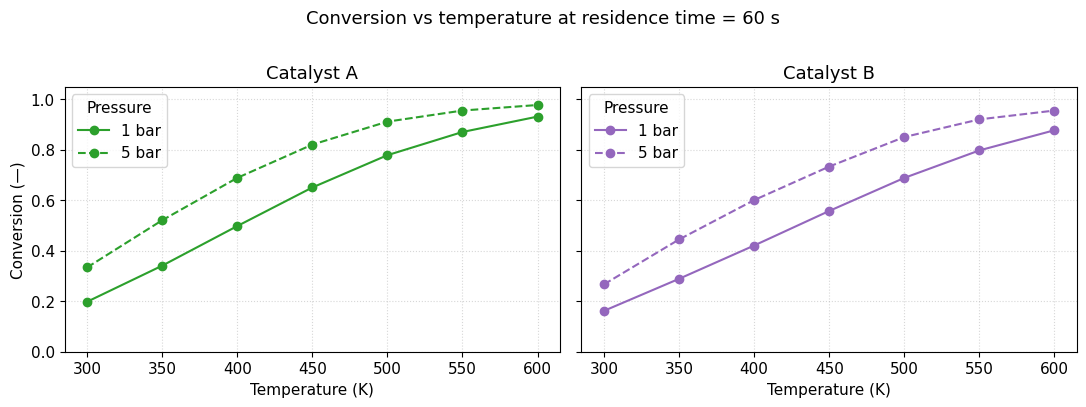

In [2]:
# Fix residence time to compare cleanly
sub = df[df['Residence_time_s'] == 60]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, cat in zip(axes, ['A', 'B']):
    for pressure, ls in PRESSURE_STYLES.items():
        d = sub[(sub['Catalyst'] == cat) & (sub['Pressure_bar'] == pressure)]
        ax.plot(d['Temperature_K'], d['Conversion'],
                color=CAT_COLORS[cat], linestyle=ls, marker='o',
                label=f'{pressure} bar')
    ax.set_title(f'Catalyst {cat}', fontsize=13)
    ax.set_xlabel('Temperature (K)')
    ax.set_ylim(0, 1.05)
    ax.legend(title='Pressure')

axes[0].set_ylabel('Conversion (—)')
fig.suptitle('Conversion vs temperature at residence time = 60 s', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Example Plot 2 — Conversion–Selectivity Trade-off
**Question:** Is there a conversion–selectivity trade-off? Does it differ by catalyst?

**Chart type rationale:** Scatter plot to show the relationship between two continuous response variables. Marker size encodes residence time as a third variable.

**Key points:**
- Classic result in reactor engineering: higher conversion often comes at the cost of selectivity
- what does the clustering by catalyst tell us? (B maintains higher selectivity at equivalent conversion)
- what does marker size tell us about residence time's role?
- Possible extension: colour by temperature instead — what changes?

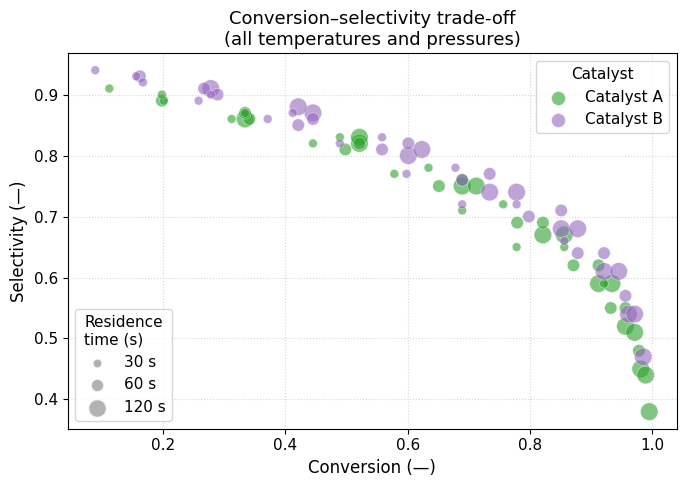

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))

for cat in ['A', 'B']:
    d = df[df['Catalyst'] == cat]
    sizes = d['Residence_time_s'].map(RT_SIZES)
    ax.scatter(d['Conversion'], d['Selectivity'],
               color=CAT_COLORS[cat], s=sizes, alpha=0.6,
               label=f'Catalyst {cat}', edgecolors='white', linewidths=0.4)

# Size legend
for rt, sz in RT_SIZES.items():
    ax.scatter([], [], s=sz, color='grey', alpha=0.6, label=f'{rt} s', edgecolors='white')

ax.set_xlabel('Conversion (—)', fontsize=12)
ax.set_ylabel('Selectivity (—)', fontsize=12)
ax.set_title('Conversion–selectivity trade-off\n(all temperatures and pressures)', fontsize=13)

# Two separate legends
handles, labels = ax.get_legend_handles_labels()
leg1 = ax.legend(handles[:2], labels[:2], title='Catalyst', loc='upper right')
ax.add_artist(leg1)
ax.legend(handles[2:], labels[2:], title='Residence\ntime (s)', loc='lower left')

plt.tight_layout()
plt.show()

---
## Example Plot 3 — Effect of Residence Time
**Question:** How does residence time affect conversion, and does temperature change the picture?

**Chart type rationale:** Line plot with residence time on x-axis, coloured by temperature. Shows saturation behaviour at high residence times clearly.

**Key poinys:**
- Fixing catalyst (A) and pressure (5 bar) to isolate these two variables
- Notice the lines converge at high residence times (diminishing returns)
- Asif you had to pick one operating point, what would it be and why?

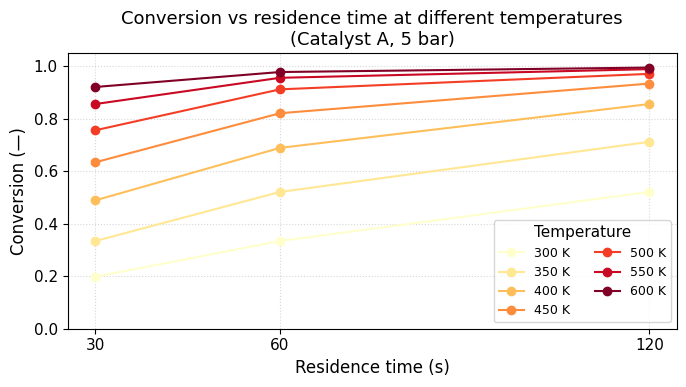

In [4]:
sub3 = df[(df['Catalyst'] == 'A') & (df['Pressure_bar'] == 5)]
temps = sorted(sub3['Temperature_K'].unique())

# Sequential colormap for temperature
cmap = plt.cm.YlOrRd
colors = [cmap(i / (len(temps) - 1)) for i in range(len(temps))]

fig, ax = plt.subplots(figsize=(7, 4))

for temp, color in zip(temps, colors):
    d = sub3[sub3['Temperature_K'] == temp].sort_values('Residence_time_s')
    ax.plot(d['Residence_time_s'], d['Conversion'],
            color=color, marker='o', label=f'{temp} K')

ax.set_xlabel('Residence time (s)', fontsize=12)
ax.set_ylabel('Conversion (—)', fontsize=12)
ax.set_title('Conversion vs residence time at different temperatures\n(Catalyst A, 5 bar)', fontsize=13)
ax.set_ylim(0, 1.05)
ax.set_xticks([30, 60, 120])
ax.legend(title='Temperature', fontsize=9, ncol=2)

plt.tight_layout()
plt.show()